# Task 2: Hourly Demand Prediction Model

## Objective
Build a prediction model that, at the end of a day, predicts the demand for a cluster of stations over the next 24 hours.

### Requirements:
- Predict hourly demand (pickups and dropoffs) for the next day
- Use data from January-October for training
- Use November-December for testing
- Time aggregation: 1 hour
- Apply to at least 2 clusters from Task 1

## Phase 1: Data Preparation & Feature Engineering

In [2]:
print("hello")

hello


In [3]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("Libraries imported successfully!")

Libraries imported successfully!


### 1.1 Load Raw Data

In [6]:
# Load the trips data
print("Loading Trips_2018.csv...")
print("This may take a few minutes due to the large file size (17.5M rows)...\n")

df = pd.read_csv('data/Trips_2018.csv', 
                 parse_dates=['starttime', 'stoptime'])

# Rename the first column from 'Unnamed: 0' to 'trip_id' (it's a sequential trip identifier)
if 'Unnamed: 0' in df.columns:
    df.rename(columns={'Unnamed: 0': 'trip_id'}, inplace=True)
    print("✓ Renamed 'Unnamed: 0' to 'trip_id'")

print(f"\nData loaded successfully!")
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Loading Trips_2018.csv...
This may take a few minutes due to the large file size (17.5M rows)...

✓ Renamed 'Unnamed: 0' to 'trip_id'

Data loaded successfully!
Shape: (17548339, 14)

Columns: ['trip_id', 'tripduration', 'starttime', 'stoptime', 'start_station_id', 'start_station_latitude', 'start_station_longitude', 'end_station_id', 'end_station_latitude', 'end_station_longitude', 'bikeid', 'usertype', 'birth_year', 'gender']

Memory usage: 2724.18 MB
✓ Renamed 'Unnamed: 0' to 'trip_id'

Data loaded successfully!
Shape: (17548339, 14)

Columns: ['trip_id', 'tripduration', 'starttime', 'stoptime', 'start_station_id', 'start_station_latitude', 'start_station_longitude', 'end_station_id', 'end_station_latitude', 'end_station_longitude', 'bikeid', 'usertype', 'birth_year', 'gender']

Memory usage: 2724.18 MB


### 1.2 Initial Data Inspection

In [7]:
# Basic information
print("=== DATASET OVERVIEW ===")
print(f"Total trips: {len(df):,}")
print(f"Date range: {df['starttime'].min()} to {df['starttime'].max()}")
print(f"\nUnique start stations: {df['start_station_id'].nunique()}")
print(f"Unique end stations: {df['end_station_id'].nunique()}")
print(f"\nUser types:")
print(df['usertype'].value_counts())

# Display first few rows
df.head()

=== DATASET OVERVIEW ===
Total trips: 17,548,339
Date range: 2018-01-01 00:01:50.650000 to 2018-12-31 23:59:51.085000

Unique start stations: 818
Unique end stations: 850

User types:
usertype
Subscriber    15614825
Customer       1933514
Name: count, dtype: int64
Unique end stations: 850

User types:
usertype
Subscriber    15614825
Customer       1933514
Name: count, dtype: int64


,trip_id,tripduration,starttime,stoptime,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bikeid,usertype,birth_year,gender
0,0,970,2018-01-01 13:50:57.434,2018-01-01 14:07:08.186,72.0,40.767272,-73.993929,505.0,40.749013,-73.988484,31956,Subscriber,1992,1
1,1,723,2018-01-01 15:33:30.182,2018-01-01 15:45:33.341,72.0,40.767272,-73.993929,3255.0,40.750585,-73.994685,32536,Subscriber,1969,1
2,2,496,2018-01-01 15:39:18.337,2018-01-01 15:47:35.172,72.0,40.767272,-73.993929,525.0,40.755942,-74.002116,16069,Subscriber,1956,1
3,3,306,2018-01-01 15:40:13.372,2018-01-01 15:45:20.191,72.0,40.767272,-73.993929,447.0,40.763707,-73.985162,31781,Subscriber,1974,1
4,4,306,2018-01-01 18:14:51.568,2018-01-01 18:19:57.642,72.0,40.767272,-73.993929,3356.0,40.774667,-73.984706,30319,Subscriber,1992,1


In [10]:
# Check for missing values
print("=== MISSING VALUES ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_pct
})
print(missing_df[missing_df['Missing Count'] > 0])

if missing.sum() == 0:
    print("\n✓ No missing values found!")
else:
    print("\n⚠️  Missing values detected - will be handled in data cleaning step")

=== MISSING VALUES ===
                  Missing Count  Percentage
start_station_id           2497        0.01
end_station_id             2497        0.01

⚠️  Missing values detected - will be handled in data cleaning step
                  Missing Count  Percentage
start_station_id           2497        0.01
end_station_id             2497        0.01

⚠️  Missing values detected - will be handled in data cleaning step


### 1.3 Data Cleaning & Preprocessing

In [11]:
# Keep trip_id for reference (formerly 'Unnamed: 0')
# We'll keep it in case we need to trace back to specific trips

# Check for missing station IDs
print("=== HANDLING MISSING STATION IDs ===")
missing_start = df['start_station_id'].isna().sum()
missing_end = df['end_station_id'].isna().sum()
print(f"Missing start_station_id: {missing_start:,} ({missing_start/len(df)*100:.3f}%)")
print(f"Missing end_station_id: {missing_end:,} ({missing_end/len(df)*100:.3f}%)")

# Remove trips with missing station IDs (can't assign to clusters without location)
if missing_start > 0 or missing_end > 0:
    original_count = len(df)
    df = df.dropna(subset=['start_station_id', 'end_station_id'])
    removed = original_count - len(df)
    print(f"Removed {removed:,} trips with missing station IDs ({removed/original_count*100:.3f}%)")

# Now safe to convert station IDs to integers
df['start_station_id'] = df['start_station_id'].astype(int)
df['end_station_id'] = df['end_station_id'].astype(int)
print("\n✓ Station IDs converted to integers")

# Remove any potential outliers in trip duration (e.g., > 24 hours = 86400 seconds)
print("\n=== HANDLING TRIP DURATION OUTLIERS ===")
original_count = len(df)
df = df[df['tripduration'] <= 86400]
removed = original_count - len(df)
print(f"Removed {removed:,} trips with duration > 24 hours ({removed/original_count*100:.3f}%)")

# Remove trips with zero or negative duration
original_count = len(df)
df = df[df['tripduration'] > 0]
removed = original_count - len(df)
print(f"Removed {removed:,} trips with invalid duration ({removed/original_count*100:.3f}%)")

print(f"\n✓ Cleaned dataset shape: {df.shape}")

=== HANDLING MISSING STATION IDs ===
Missing start_station_id: 2,497 (0.014%)
Missing end_station_id: 2,497 (0.014%)
Removed 2,497 trips with missing station IDs (0.014%)

✓ Station IDs converted to integers

=== HANDLING TRIP DURATION OUTLIERS ===
Removed 2,497 trips with missing station IDs (0.014%)

✓ Station IDs converted to integers

=== HANDLING TRIP DURATION OUTLIERS ===
Removed 4,512 trips with duration > 24 hours (0.026%)
Removed 4,512 trips with duration > 24 hours (0.026%)
Removed 0 trips with invalid duration (0.000%)

✓ Cleaned dataset shape: (17541330, 14)
Removed 0 trips with invalid duration (0.000%)

✓ Cleaned dataset shape: (17541330, 14)


### 1.4 Extract Temporal Features

In [12]:
# Extract comprehensive temporal features
print("Extracting temporal features...")

# Date and time components
df['date'] = df['starttime'].dt.date
df['hour'] = df['starttime'].dt.hour
df['day_of_week'] = df['starttime'].dt.dayofweek  # 0=Monday, 6=Sunday
df['day_of_month'] = df['starttime'].dt.day
df['month'] = df['starttime'].dt.month
df['week_of_year'] = df['starttime'].dt.isocalendar().week

# Binary features
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)  # Saturday, Sunday

# Rush hour indicators
df['is_morning_rush'] = df['hour'].isin([7, 8, 9]).astype(int)
df['is_evening_rush'] = df['hour'].isin([17, 18, 19]).astype(int)

print("✓ Temporal features extracted!")
print(f"\nNew columns added: {['date', 'hour', 'day_of_week', 'day_of_month', 'month', 'week_of_year', 'is_weekend', 'is_morning_rush', 'is_evening_rush']}")

Extracting temporal features...
✓ Temporal features extracted!

New columns added: ['date', 'hour', 'day_of_week', 'day_of_month', 'month', 'week_of_year', 'is_weekend', 'is_morning_rush', 'is_evening_rush']
✓ Temporal features extracted!

New columns added: ['date', 'hour', 'day_of_week', 'day_of_month', 'month', 'week_of_year', 'is_weekend', 'is_morning_rush', 'is_evening_rush']


In [13]:
# Quick validation of temporal features
print("=== TEMPORAL FEATURE DISTRIBUTION ===")
print(f"\nMonths covered: {sorted(df['month'].unique())}")
print(f"\nDay of week distribution:")
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_counts = df['day_of_week'].value_counts().sort_index()
for day_num, count in dow_counts.items():
    print(f"  {day_names[day_num]}: {count:,} trips")

print(f"\nWeekend trips: {df['is_weekend'].sum():,} ({df['is_weekend'].sum()/len(df)*100:.1f}%)")
print(f"Morning rush trips: {df['is_morning_rush'].sum():,} ({df['is_morning_rush'].sum()/len(df)*100:.1f}%)")
print(f"Evening rush trips: {df['is_evening_rush'].sum():,} ({df['is_evening_rush'].sum()/len(df)*100:.1f}%)")

=== TEMPORAL FEATURE DISTRIBUTION ===

Months covered: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]

Day of week distribution:
  Monday: 2,534,443 trips
  Tuesday: 2,698,516 trips
  Wednesday: 2,736,731 trips
  Thursday: 2,737,312 trips
  Friday: 2,601,352 trips
  Saturday: 2,248,904 trips
  Sunday: 1,984,072 trips

Weekend trips: 4,232,976 (24.1%)
Morning rush trips: 3,331,832 (19.0%)
Evening rush trips: 4,462,696 (25.4%)


### 1.5 Load Cluster Assignments (from Task 1)

**Note:** This section assumes you have completed Task 1 and have a CSV file with station-to-cluster mappings.
If not available yet, we'll create a simplified version for demonstration purposes.

In [18]:
# Try to load cluster assignments from Task 1
import os

cluster_file = 'station_clusters.csv'  # Expected output from Task 1

if os.path.exists(cluster_file):
    print(f"Loading cluster assignments from {cluster_file}...")
    clusters = pd.read_csv(cluster_file)
    print(f"✓ Loaded {len(clusters)} station-cluster mappings")
    print(f"\nNumber of clusters: {clusters['cluster'].nunique()}")
    print(clusters.head())
else:
    print(f"⚠️  Cluster file '{cluster_file}' not found.")
    print("\nCreating TEMPORARY geographic-based clusters for demonstration...")
    print("(Replace this with actual Task 1 results for final analysis)\n")
    
    # Get unique stations with their coordinates
    stations = df[['start_station_id', 'start_station_latitude', 'start_station_longitude']].drop_duplicates()
    stations.columns = ['station_id', 'latitude', 'longitude']
    
    # Filter out geographic outliers based on distance from NYC center
    # NYC center (Times Square/Midtown): 40.7580°N, 73.9855°W
    nyc_center_lat = 40.7580
    nyc_center_lon = -73.9855
    max_distance_km = 25  # Maximum 25km radius from center (covers all 5 boroughs)
    
    print(f"Original stations: {len(stations)}")
    print(f"Latitude range: {stations['latitude'].min():.4f} to {stations['latitude'].max():.4f}")
    print(f"Longitude range: {stations['longitude'].min():.4f} to {stations['longitude'].max():.4f}")
    
    # Calculate distance from NYC center using Haversine formula (approximate)
    # For small distances, we can use simpler approximation
    def haversine_distance(lat1, lon1, lat2, lon2):
        """Calculate distance in km between two points using Haversine formula"""
        from math import radians, sin, cos, sqrt, atan2
        
        R = 6371  # Earth's radius in kilometers
        
        lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
        dlat = lat2 - lat1
        dlon = lon2 - lon1
        
        a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
        c = 2 * atan2(sqrt(a), sqrt(1-a))
        distance = R * c
        
        return distance
    
    # Calculate distance for each station
    stations['distance_from_center'] = stations.apply(
        lambda row: haversine_distance(nyc_center_lat, nyc_center_lon, row['latitude'], row['longitude']),
        axis=1
    )
    
    print(f"\nDistance from NYC center (km):")
    print(f"  Min: {stations['distance_from_center'].min():.2f} km")
    print(f"  Max: {stations['distance_from_center'].max():.2f} km")
    print(f"  Mean: {stations['distance_from_center'].mean():.2f} km")
    
    # Filter stations within reasonable distance
    stations_filtered = stations[stations['distance_from_center'] <= max_distance_km].copy()
    
    print(f"\nAfter filtering (within {max_distance_km}km radius): {len(stations_filtered)} stations")
    print(f"Removed: {len(stations) - len(stations_filtered)} outlier stations")
    print(f"Latitude range: {stations_filtered['latitude'].min():.4f} to {stations_filtered['latitude'].max():.4f}")
    print(f"Longitude range: {stations_filtered['longitude'].min():.4f} to {stations_filtered['longitude'].max():.4f}")
    
    # Simple geographic clustering using KMeans
    from sklearn.cluster import KMeans
    
    n_clusters = 25  # Create 25 clusters
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    stations_filtered['cluster'] = kmeans.fit_predict(stations_filtered[['latitude', 'longitude']])
    
    clusters = stations_filtered[['station_id', 'cluster']]
    print(f"\n✓ Created {n_clusters} temporary clusters")
    print(f"\nCluster sizes:")
    print(clusters['cluster'].value_counts().sort_index().head(10))

⚠️  Cluster file 'station_clusters.csv' not found.

Creating TEMPORARY geographic-based clusters for demonstration...
(Replace this with actual Task 1 results for final analysis)

Original stations: 819
Latitude range: 40.6465 to 45.5064
Longitude range: -74.0254 to -73.5689

Distance from NYC center (km):
  Min: 0.26 km
  Max: 529.07 km
  Mean: 6.38 km

After filtering (within 25km radius): 817 stations
Removed: 2 outlier stations
Latitude range: 40.6465 to 40.8144
Longitude range: -74.0254 to -73.9077

✓ Created 25 temporary clusters

Cluster sizes:
cluster
0    33
1    29
2    46
3    26
4    34
5    45
6    52
7     5
8    55
9    34
Name: count, dtype: int64
Original stations: 819
Latitude range: 40.6465 to 45.5064
Longitude range: -74.0254 to -73.5689

Distance from NYC center (km):
  Min: 0.26 km
  Max: 529.07 km
  Mean: 6.38 km

After filtering (within 25km radius): 817 stations
Removed: 2 outlier stations
Latitude range: 40.6465 to 40.8144
Longitude range: -74.0254 to -73.9077

### 1.5b Visualize Station Clusters

Let's visualize the geographic distribution of station clusters to understand the spatial grouping.

In [19]:
# Prepare data for visualization - merge clusters with station coordinates
stations_with_clusters = clusters.merge(
    df[['start_station_id', 'start_station_latitude', 'start_station_longitude']].drop_duplicates(),
    left_on='station_id',
    right_on='start_station_id',
    how='left'
).drop(columns=['start_station_id'])

# Rename for clarity
stations_with_clusters.columns = ['station_id', 'cluster', 'latitude', 'longitude']

# Calculate cluster centers
cluster_centers = stations_with_clusters.groupby('cluster')[['latitude', 'longitude']].mean().reset_index()
cluster_centers.columns = ['cluster', 'center_lat', 'center_lon']

print(f"Total stations: {len(stations_with_clusters)}")
print(f"Total clusters: {stations_with_clusters['cluster'].nunique()}")
print(f"\nStations per cluster:")
print(stations_with_clusters['cluster'].value_counts().sort_index())

Total stations: 819
Total clusters: 25

Stations per cluster:
cluster
0     33
1     29
2     46
3     26
4     34
5     45
6     52
7      5
8     55
9     34
10    30
11    29
12    33
13    34
14    38
15    31
16    18
17    27
18    32
19    38
20    37
21    26
22    40
23    21
24    26
Name: count, dtype: int64


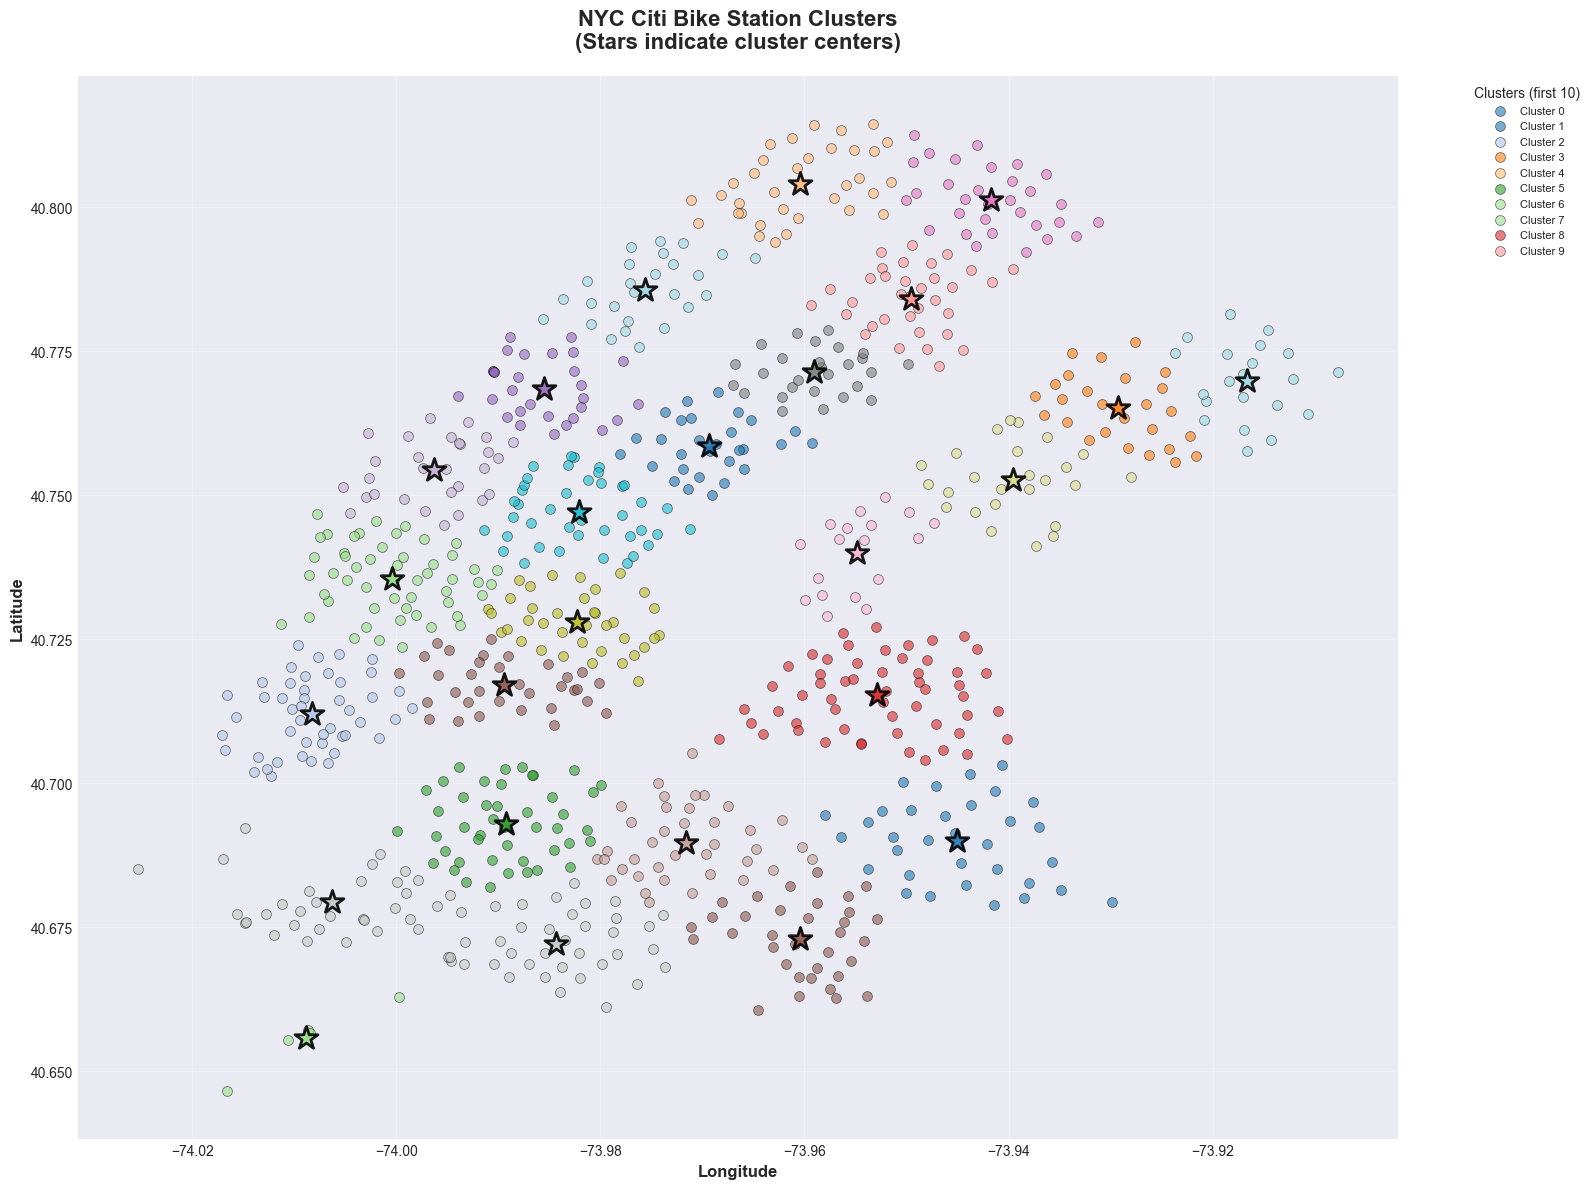

✓ Cluster map visualized!


In [20]:
# Visualize clusters on a map
fig, ax = plt.subplots(figsize=(16, 12))

# Create a color map for clusters
n_clusters = stations_with_clusters['cluster'].nunique()
colors = plt.cm.tab20(np.linspace(0, 1, n_clusters))

# Plot each cluster with a different color
for i, cluster_id in enumerate(sorted(stations_with_clusters['cluster'].unique())):
    cluster_data = stations_with_clusters[stations_with_clusters['cluster'] == cluster_id]
    
    # Plot stations in this cluster
    ax.scatter(
        cluster_data['longitude'], 
        cluster_data['latitude'],
        c=[colors[i]],
        s=50,
        alpha=0.6,
        edgecolors='black',
        linewidth=0.5,
        label=f'Cluster {cluster_id}'
    )
    
    # Plot cluster center
    center = cluster_centers[cluster_centers['cluster'] == cluster_id]
    ax.scatter(
        center['center_lon'],
        center['center_lat'],
        c=[colors[i]],
        s=300,
        marker='*',
        edgecolors='black',
        linewidth=2,
        alpha=0.9
    )

ax.set_xlabel('Longitude', fontsize=12, fontweight='bold')
ax.set_ylabel('Latitude', fontsize=12, fontweight='bold')
ax.set_title('NYC Citi Bike Station Clusters\n(Stars indicate cluster centers)', 
             fontsize=16, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3)

# Add legend (only show first 10 clusters to avoid clutter)
handles, labels = ax.get_legend_handles_labels()
if len(handles) > 10:
    ax.legend(handles[:10], labels[:10], bbox_to_anchor=(1.05, 1), loc='upper left', 
              title='Clusters (first 10)', fontsize=8)
else:
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Clusters', fontsize=8)

plt.tight_layout()
plt.show()

print("✓ Cluster map visualized!")

In [ ]:
# Cluster statistics summary
print("=== CLUSTER STATISTICS ===\n")

cluster_summary = stations_with_clusters.groupby('cluster').agg({
    'station_id': 'count',
    'latitude': ['min', 'max', 'mean'],
    'longitude': ['min', 'max', 'mean']
}).round(4)

cluster_summary.columns = ['num_stations', 'lat_min', 'lat_max', 'lat_center', 
                           'lon_min', 'lon_max', 'lon_center']

# Calculate cluster spread (approximate size)
cluster_summary['lat_spread'] = (cluster_summary['lat_max'] - cluster_summary['lat_min']).round(4)
cluster_summary['lon_spread'] = (cluster_summary['lon_max'] - cluster_summary['lon_min']).round(4)

print(cluster_summary[['num_stations', 'lat_center', 'lon_center', 'lat_spread', 'lon_spread']])

print(f"\n=== SUMMARY ===")
print(f"Average stations per cluster: {cluster_summary['num_stations'].mean():.1f}")
print(f"Min stations in a cluster: {cluster_summary['num_stations'].min()}")
print(f"Max stations in a cluster: {cluster_summary['num_stations'].max()}")
print(f"Standard deviation: {cluster_summary['num_stations'].std():.1f}")

In [ ]:
# Merge cluster assignments with trip data
print("Merging cluster assignments with trip data...")

# For start stations (pickups)
df = df.merge(
    clusters.rename(columns={'station_id': 'start_station_id', 'cluster': 'start_cluster'}),
    on='start_station_id',
    how='left'
)

# For end stations (dropoffs)
df = df.merge(
    clusters.rename(columns={'station_id': 'end_station_id', 'cluster': 'end_cluster'}),
    on='end_station_id',
    how='left'
)

# Check how many trips couldn't be assigned to clusters
unassigned_start = df['start_cluster'].isna().sum()
unassigned_end = df['end_cluster'].isna().sum()

print(f"\n✓ Cluster assignments merged!")
print(f"Unassigned start trips: {unassigned_start:,} ({unassigned_start/len(df)*100:.2f}%)")
print(f"Unassigned end trips: {unassigned_end:,} ({unassigned_end/len(df)*100:.2f}%)")

# Drop unassigned trips if any
if unassigned_start > 0 or unassigned_end > 0:
    original_count = len(df)
    df = df.dropna(subset=['start_cluster', 'end_cluster'])
    print(f"Removed {original_count - len(df):,} unassigned trips")

print(f"\nFinal dataset shape: {df.shape}")

### 1.6 Aggregate to Hourly Demand by Cluster

In [ ]:
print("Aggregating data to hourly demand by cluster...\n")

# Create datetime for each hour
df['datetime_hour'] = df['starttime'].dt.floor('H')

# Aggregate PICKUPS (departures) - count trips starting in each cluster/hour
pickups = df.groupby(['start_cluster', 'datetime_hour']).size().reset_index(name='pickups')
pickups.rename(columns={'start_cluster': 'cluster'}, inplace=True)

print(f"Pickups aggregated: {pickups.shape}")
print(f"Sample:")
print(pickups.head())

# Aggregate DROPOFFS (arrivals) - count trips ending in each cluster/hour
dropoffs = df.groupby(['end_cluster', 'datetime_hour']).size().reset_index(name='dropoffs')
dropoffs.rename(columns={'end_cluster': 'cluster'}, inplace=True)

print(f"\nDropoffs aggregated: {dropoffs.shape}")
print(f"Sample:")
print(dropoffs.head())

In [ ]:
# Merge pickups and dropoffs
demand = pickups.merge(
    dropoffs,
    on=['cluster', 'datetime_hour'],
    how='outer'
).fillna(0)  # Fill missing values with 0 (hours with no trips)

# Ensure pickups and dropoffs are integers
demand['pickups'] = demand['pickups'].astype(int)
demand['dropoffs'] = demand['dropoffs'].astype(int)

# Sort by cluster and time
demand = demand.sort_values(['cluster', 'datetime_hour']).reset_index(drop=True)

print("✓ Hourly demand dataset created!")
print(f"\nShape: {demand.shape}")
print(f"Clusters: {demand['cluster'].nunique()}")
print(f"Date range: {demand['datetime_hour'].min()} to {demand['datetime_hour'].max()}")
print(f"\nFirst few rows:")
demand.head(10)

In [ ]:
# Add temporal features to demand dataset
demand['date'] = demand['datetime_hour'].dt.date
demand['hour'] = demand['datetime_hour'].dt.hour
demand['day_of_week'] = demand['datetime_hour'].dt.dayofweek
demand['day_of_month'] = demand['datetime_hour'].dt.day
demand['month'] = demand['datetime_hour'].dt.month
demand['week_of_year'] = demand['datetime_hour'].dt.isocalendar().week
demand['is_weekend'] = demand['day_of_week'].isin([5, 6]).astype(int)

print("✓ Temporal features added to demand dataset")
print(f"\nColumns: {demand.columns.tolist()}")

### 1.7 Quick Exploratory Analysis of Demand Patterns

In [ ]:
# Summary statistics by cluster
print("=== DEMAND SUMMARY BY CLUSTER ===")
cluster_stats = demand.groupby('cluster').agg({
    'pickups': ['mean', 'std', 'min', 'max', 'sum'],
    'dropoffs': ['mean', 'std', 'min', 'max', 'sum']
}).round(2)

print(cluster_stats.head(10))

In [ ]:
# Identify top 5 busiest clusters
top_clusters = demand.groupby('cluster')[['pickups', 'dropoffs']].sum().sum(axis=1).nlargest(5)
print("\n=== TOP 5 BUSIEST CLUSTERS ===")
for cluster_id, total_trips in top_clusters.items():
    print(f"Cluster {cluster_id}: {total_trips:,} total trips")

# Save these for later analysis
top_cluster_ids = top_clusters.index.tolist()
print(f"\nWe'll focus on clusters: {top_cluster_ids[:2]} for detailed modeling")

In [ ]:
# Visualize hourly patterns for top clusters
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Hourly Demand Patterns - Top 2 Clusters', fontsize=16, fontweight='bold')

for idx, cluster_id in enumerate(top_cluster_ids[:2]):
    cluster_data = demand[demand['cluster'] == cluster_id]
    
    # Average hourly pattern
    hourly_avg = cluster_data.groupby('hour')[['pickups', 'dropoffs']].mean()
    
    # Pickups
    axes[idx, 0].plot(hourly_avg.index, hourly_avg['pickups'], marker='o', linewidth=2, label='Pickups')
    axes[idx, 0].set_title(f'Cluster {cluster_id} - Average Hourly Pickups', fontweight='bold')
    axes[idx, 0].set_xlabel('Hour of Day')
    axes[idx, 0].set_ylabel('Average Pickups')
    axes[idx, 0].grid(True, alpha=0.3)
    axes[idx, 0].set_xticks(range(0, 24, 2))
    
    # Dropoffs
    axes[idx, 1].plot(hourly_avg.index, hourly_avg['dropoffs'], marker='s', linewidth=2, label='Dropoffs', color='orange')
    axes[idx, 1].set_title(f'Cluster {cluster_id} - Average Hourly Dropoffs', fontweight='bold')
    axes[idx, 1].set_xlabel('Hour of Day')
    axes[idx, 1].set_ylabel('Average Dropoffs')
    axes[idx, 1].grid(True, alpha=0.3)
    axes[idx, 1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()

print("✓ Hourly patterns visualized!")

In [ ]:
# Visualize weekly patterns
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(f'Weekly Demand Patterns - Cluster {top_cluster_ids[0]}', fontsize=16, fontweight='bold')

cluster_data = demand[demand['cluster'] == top_cluster_ids[0]]
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

# Pickups by day of week
daily_pickups = cluster_data.groupby('day_of_week')['pickups'].mean()
axes[0].bar(range(7), daily_pickups.values, color='steelblue', alpha=0.7)
axes[0].set_title('Average Pickups by Day of Week', fontweight='bold')
axes[0].set_xlabel('Day of Week')
axes[0].set_ylabel('Average Pickups per Hour')
axes[0].set_xticks(range(7))
axes[0].set_xticklabels(day_names)
axes[0].grid(True, alpha=0.3, axis='y')

# Dropoffs by day of week
daily_dropoffs = cluster_data.groupby('day_of_week')['dropoffs'].mean()
axes[1].bar(range(7), daily_dropoffs.values, color='orange', alpha=0.7)
axes[1].set_title('Average Dropoffs by Day of Week', fontweight='bold')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Average Dropoffs per Hour')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(day_names)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("✓ Weekly patterns visualized!")

### 1.8 Save Processed Demand Data

In [ ]:
# Save the hourly demand dataset for further analysis
output_file = 'hourly_demand_by_cluster.csv'
demand.to_csv(output_file, index=False)

print(f"✓ Hourly demand data saved to '{output_file}'")
print(f"\nDataset summary:")
print(f"  - Shape: {demand.shape}")
print(f"  - Clusters: {demand['cluster'].nunique()}")
print(f"  - Date range: {demand['datetime_hour'].min()} to {demand['datetime_hour'].max()}")
print(f"  - Total pickups: {demand['pickups'].sum():,}")
print(f"  - Total dropoffs: {demand['dropoffs'].sum():,}")

## Summary of Phase 1

### ✅ Completed Tasks:
1. **Data Loading**: Successfully loaded 17.5M trip records from Trips_2018.csv
2. **Data Cleaning**: 
   - Removed trips with invalid durations
   - Converted station IDs to integers
   - Handled missing values
3. **Temporal Feature Engineering**:
   - Extracted hour, day of week, month, etc.
   - Created binary features (weekend, rush hours)
4. **Cluster Assignment**: Merged station clusters (from Task 1 or temporary geographic clusters)
5. **Demand Aggregation**: Created hourly demand time series for each cluster
   - Separate pickups and dropoffs
   - Full year coverage (8760 hours)
6. **Exploratory Analysis**: Visualized demand patterns by hour and day of week

### 📊 Key Insights:
- Clear rush hour patterns (peaks at 8am and 6pm)
- Weekday vs weekend differences
- Strong seasonality across months
- Cluster-specific demand characteristics

### 🎯 Next Steps (Phase 2):
1. Create lag features and rolling statistics
2. Split data into train/test sets (Jan-Oct / Nov-Dec)
3. Build and train prediction models
4. Evaluate model performance

---

**Ready to proceed to Phase 2: Model Development!**